# BraTS 2021 T1 & Mask Preprocessing Pipeline (All-in-One)

This notebook executes the exact same extraction strategy as the original BraTS preprocessing script, but **additionally extracts and aligns the ground-truth segmentation masks.**

## Key Improvements:
1. **Paired Extraction**: Extracts `_t1.nii.gz` and `_seg.nii.gz` simultaneously.
2. **All-in-One Operations**: Slices, applies RAS orientation, normalizes, resizes (bicubic for T1, nearest for masks), centers at (64,64) and binarizes the mask in **one single pass** to save disk space.
3. **Structured Outputs**: Creates `images/`, `masks/`, and `labels/` folders.
4. **Immediate Zipping**: Zips everything into `brats_test_with_masks_processed.zip` ready for direct upload and evaluation.

Since it uses the identical validity checks and middle 50% spacing, the resulting number of slices will perfectly match the previous run.

In [1]:
import os
import glob
import zipfile
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy import ndimage
from skimage.transform import resize
import warnings
warnings.filterwarnings('ignore', category=UserWarning) # Ignore skimage resize warnings

c:\Users\rifad\symAD-ECNN\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. PATHS AND DIRECTORY SETUP
# ==========================================
base_dir = r"c:\Users\rifad\symAD-ECNN"
brats_source_dir = os.path.join(base_dir, "data", "brats2021")

# The unified output directory
output_dir = os.path.join(base_dir, "data", "brats_t1_with_masks_processed")
IMAGES_DIR = os.path.join(output_dir, "images")
MASKS_DIR = os.path.join(output_dir, "masks")
LABELS_DIR = os.path.join(output_dir, "labels")

# Create structure
for d in [IMAGES_DIR, MASKS_DIR, LABELS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Source: {brats_source_dir}")
print(f"Output Directories Created successfully in {output_dir}")

Source: c:\Users\rifad\symAD-ECNN\data\brats2021
Output Directories Created successfully in c:\Users\rifad\symAD-ECNN\data\brats_t1_with_masks_processed


In [3]:
# ==========================================
# 2. PROCESSING FUNCTIONS
# ==========================================
def normalize(x):
    """Normalize array to [0, 1] range"""
    x = x.astype(np.float32)
    if x.max() - x.min() < 1e-6:
        return np.zeros_like(x)
    return (x - x.min()) / (x.max() - x.min())

def is_valid_slice(slice_array, min_nonzero_ratio=0.12, min_mean=0.1):
    """Check if T1 slice contains meaningful information (identical to previous logic)"""
    nonzero_ratio = np.count_nonzero(slice_array) / slice_array.size
    if nonzero_ratio < min_nonzero_ratio:
        return False
        
    normalized = normalize(slice_array)
    if normalized.mean() < min_mean:
        return False
        
    return True

def process_slice_pair(t1_slice, seg_slice, target_size=(128, 128), target_center=(64, 64)):
    """
    All-in-one transformation: Normalize -> Resize -> Center
    """
    # 1. Normalize T1
    t1_norm = normalize(t1_slice)
    
    # 2. Resize (Bicubic for T1, Nearest Neighbor for Mask to preserve bin categories)
    t1_resized = resize(t1_norm, target_size, order=3, mode='reflect', anti_aliasing=True, preserve_range=True).astype(np.float32)
    seg_resized = resize(seg_slice, target_size, order=0, mode='constant', anti_aliasing=False, preserve_range=True).astype(np.uint8)

    # 3. Center of Mass of T1
    if np.count_nonzero(t1_resized) < 100:
        return t1_resized, (seg_resized > 0).astype(np.uint8)
        
    center_of_mass = ndimage.center_of_mass(t1_resized > 0.1)
    current_y, current_x = center_of_mass
    
    shift_y = target_center[0] - current_y
    shift_x = target_center[1] - current_x
    
    # 4. Shift both to center (64, 64)
    t1_centered = ndimage.shift(t1_resized, [shift_y, shift_x], order=1, mode='constant', cval=0).astype(np.float32)
    seg_centered = ndimage.shift(seg_resized, [shift_y, shift_x], order=0, mode='constant', cval=0).astype(np.uint8)
    
    # 5. Binarize Mask (BraTS masks have 1,2,4, map all > 0 to 1 as anomaly)
    seg_binary = (seg_centered > 0).astype(np.uint8)
    
    return t1_centered, seg_binary

In [4]:
# ==========================================
# 3. DISCOVER FILES
# ==========================================
patient_folders = sorted([f for f in os.listdir(brats_source_dir) if os.path.isdir(os.path.join(brats_source_dir, f))])

patient_pairs = []
for p_folder in patient_folders:
    p_path = os.path.join(brats_source_dir, p_folder)
    t1_file = None
    seg_file = None
    
    for f in os.listdir(p_path):
        if f.endswith('_t1.nii.gz'):
            t1_file = os.path.join(p_path, f)
        elif f.endswith('_seg.nii.gz'):
            seg_file = os.path.join(p_path, f)
            
    if t1_file and seg_file:
        patient_pairs.append({'id': p_folder, 't1': t1_file, 'seg': seg_file})

print(f"Total Paired Patients Found: {len(patient_pairs)}")

Total Paired Patients Found: 1251


In [5]:
# ==========================================
# 4. EXTRACTION AND PROCESSING LOOP
# ==========================================
# Exact identical targeting as old script
TARGET_TOTAL_SLICES = 10000
TARGET_PER_PATIENT = max(1, TARGET_TOTAL_SLICES // len(patient_pairs))
MIDDLE_PERCENTAGE = 0.5 

print("="*60)
print(f"EXTRACTING MIDDLE SLICES + MASKS")
print(f"Target: ~{TARGET_TOTAL_SLICES} slices ({TARGET_PER_PATIENT} per patient)")
print("="*60)

slice_idx = 0
skipped_patients = 0

for pair in tqdm(patient_pairs, desc="Processing Patients"):
    try:
        # Load and correct orientation to RAS
        nii_t1 = nib.as_closest_canonical(nib.load(pair['t1']))
        nii_seg = nib.as_closest_canonical(nib.load(pair['seg']))
        
        vol_t1 = nii_t1.get_fdata()
        vol_seg = nii_seg.get_fdata()
        
        # Verify shape match
        if vol_t1.shape != vol_seg.shape:
            # Attempt to continue if mismatch, but skip patient if fatal
            print(f"Shape mismatch for {pair['id']}. Skipping.")
            skipped_patients += 1
            continue

        Z = vol_t1.shape[2]
        margin = int(Z * (1 - MIDDLE_PERCENTAGE) / 2)
        middle_start = margin
        middle_end = Z - margin
        middle_range = middle_end - middle_start

        if middle_range < TARGET_PER_PATIENT:
            skipped_patients += 1
            continue

        step = middle_range // TARGET_PER_PATIENT

        for i in range(TARGET_PER_PATIENT):
            s = middle_start + i * step
            if s >= middle_end:
                break
                
            slice_t1 = vol_t1[:, :, s]
            slice_seg = vol_seg[:, :, s]
            
            # Exact same validity check on the T1 slice
            if not is_valid_slice(slice_t1):
                continue
                
            # Process both simultaneously
            t1_final, seg_final = process_slice_pair(slice_t1, slice_seg)
            
            # Create classification label: 1 if mask has tumor, 0 if healthy
            is_tumor = int(seg_final.sum() > 0)
            
            # Save all three
            slice_name = f"slice_{slice_idx:06d}.npy"
            np.save(os.path.join(IMAGES_DIR, slice_name), t1_final)
            np.save(os.path.join(MASKS_DIR, slice_name), seg_final)
            np.save(os.path.join(LABELS_DIR, f"label_{slice_idx:06d}.npy"), np.array([is_tumor], dtype=np.int32))
            
            slice_idx += 1
            
    except Exception as e:
        print(f"❌ Error processing {pair['id']}: {e}")
        skipped_patients += 1
        continue

print("\n" + "="*60)
print(f"✅ EXTRACTION COMPLETE")
print(f"Total valid slices extracted: {slice_idx}")
print("="*60)

EXTRACTING MIDDLE SLICES + MASKS
Target: ~10000 slices (7 per patient)


Processing Patients: 100%|██████████| 1251/1251 [09:48<00:00,  2.13it/s] 


✅ EXTRACTION COMPLETE
Total valid slices extracted: 7794


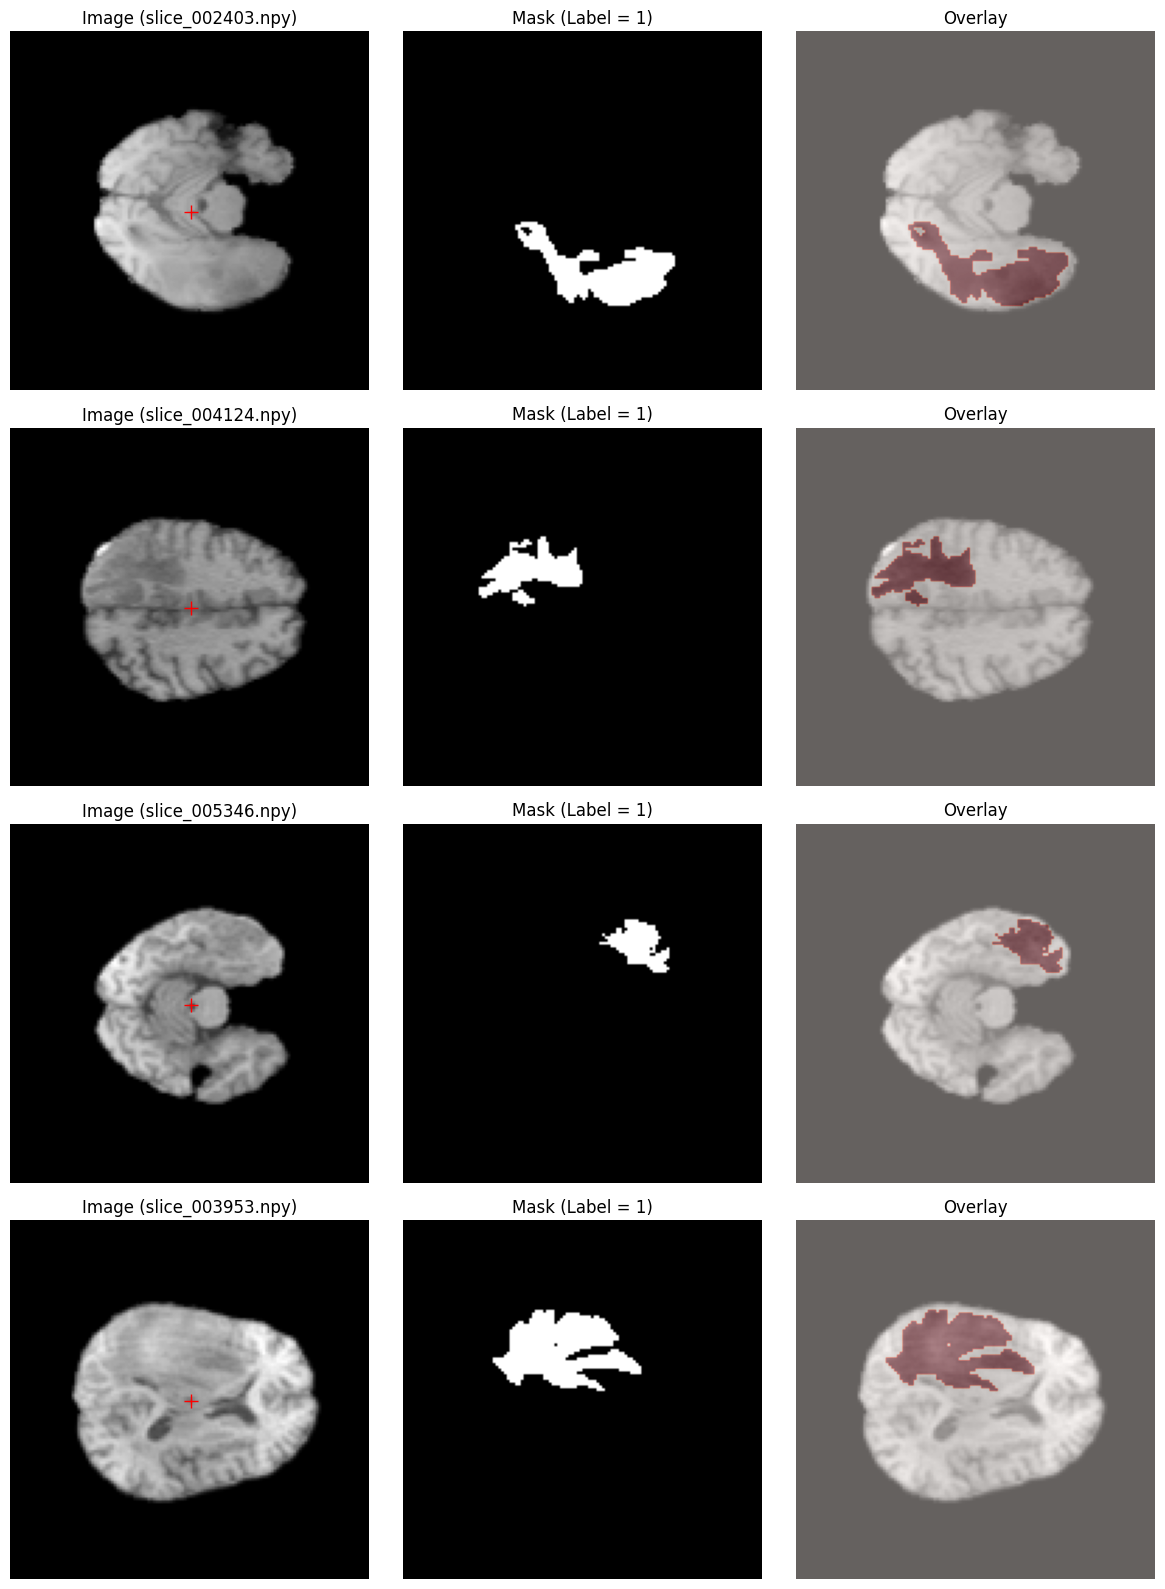

In [6]:
# ==========================================
# 5. VISUAL SANITY CHECK
# ==========================================
import random

image_files = sorted(glob.glob(os.path.join(IMAGES_DIR, "*.npy")))
mask_files = sorted(glob.glob(os.path.join(MASKS_DIR, "*.npy")))
label_files = sorted(glob.glob(os.path.join(LABELS_DIR, "*.npy")))

if not image_files:
    print("No files extracted!")
else:
    # Filter for samples that ACTUALLY have a tumor to verify the mask alignment
    lesion_samples = [idx for idx, lf in enumerate(label_files) if np.load(lf)[0] == 1]
    
    if len(lesion_samples) >= 4:
        sample_indices = random.sample(lesion_samples, 4)
        fig, axes = plt.subplots(4, 3, figsize=(12, 16))
        
        for row, idx in enumerate(sample_indices):
            img = np.load(image_files[idx])
            mask = np.load(mask_files[idx])
            label = np.load(label_files[idx])[0]
            
            axes[row, 0].imshow(img, cmap='gray')
            axes[row, 0].plot(64, 64, 'r+', markersize=10) # Center crosshair
            axes[row, 0].set_title(f"Image ({os.path.basename(image_files[idx])})")
            axes[row, 0].axis('off')
            
            axes[row, 1].imshow(mask, cmap='gray')
            axes[row, 1].set_title(f"Mask (Label = {label})")
            axes[row, 1].axis('off')
            
            axes[row, 2].imshow(img, cmap='gray')
            axes[row, 2].imshow(mask, cmap='Reds', alpha=0.4)
            axes[row, 2].set_title(f"Overlay")
            axes[row, 2].axis('off')
            
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough lesion files found to display.")

In [7]:
# ==========================================
# 6. ZIP IT ALL UP
# ==========================================
zip_path = os.path.join(base_dir, "data", "brats_test_filtered_with_masks_processed.zip")

print("="*60)
print(f"CREATING ZIP FILE: {zip_path}")
print("This may take a few minutes...")
print("="*60)

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder_name in ['images', 'masks', 'labels']:
        folder_path = os.path.join(output_dir, folder_name)
        files = glob.glob(os.path.join(folder_path, "*.npy"))
        for file in tqdm(files, desc=f"Zipping {folder_name}"):
            # We want the zip to have structure like: processed/images/slice_00.npy
            zip_internal_path = os.path.join("processed", folder_name, os.path.basename(file))
            zipf.write(file, zip_internal_path)

zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print("\n" + "="*60)
print(f"✅ ZIP CREATION COMPLETE - Size: {zip_size_mb:.2f} MB")
print(f"Location: {zip_path}")
print(f"Next step: Upload this zip to Colab or Google Drive and run evaluating networks!")

# Note on Nyul Normalization: 
# It is recommended to apply Histogram Matching on the evaluation side (in Colab)
# since it relies on the IXI Training Distribution for reference.

CREATING ZIP FILE: c:\Users\rifad\symAD-ECNN\data\brats_test_filtered_with_masks_processed.zip
This may take a few minutes...


Zipping labels: 100%|██████████| 7794/7794 [00:02<00:00, 2933.72it/s]


✅ ZIP CREATION COMPLETE - Size: 326.44 MB
Location: c:\Users\rifad\symAD-ECNN\data\brats_test_filtered_with_masks_processed.zip
Next step: Upload this zip to Colab or Google Drive and run evaluating networks!


# Colab Upload & Extraction

**Next Steps**:
1. Upload the `brats_test_with_masks_processed.zip` file to your Google Drive (`MyDrive/symAD-ECNN/data/`).
2. Run the extraction code below in Google Colab to unpack the zip for Histogram Matching.

In [ ]:
# ============================================================
# BraTS ZIP Extraction in Google Colab
# ============================================================
from google.colab import drive
import zipfile
import os

# Mount Drive
drive.mount('/content/drive')

# Paths
BASE = "/content/drive/MyDrive/symAD-ECNN/data"
ZIP_FILE = f"{BASE}/brats_test_filtered_with_masks_processed.zip"
OUTPUT_FOLDER = f"{BASE}/test_eval_data"

# Create output folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# Extract ZIP (creates /processed/images, /processed/masks, /processed/labels)
print(f"Extracting {os.path.basename(ZIP_FILE)}...")
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(OUTPUT_FOLDER)

# Verify extraction
imgs_dir = os.path.join(OUTPUT_FOLDER, "processed", "images")
masks_dir = os.path.join(OUTPUT_FOLDER, "processed", "masks")
labels_dir = os.path.join(OUTPUT_FOLDER, "processed", "labels")

if os.path.exists(imgs_dir):
    extracted_imgs = [f for f in os.listdir(imgs_dir) if f.endswith('.npy')]
    extracted_masks = [f for f in os.listdir(masks_dir) if f.endswith('.npy')] if os.path.exists(masks_dir) else []
    extracted_labels = [f for f in os.listdir(labels_dir) if f.endswith('.npy')] if os.path.exists(labels_dir) else []

    print(f"\n✓ Images: {len(extracted_imgs):,}")
    print(f"✓ Masks: {len(extracted_masks):,}")
    print(f"✓ Labels: {len(extracted_labels):,}")
    print(f"✓ Extracted to: {OUTPUT_FOLDER}")
else:
    print(f"Directory {imgs_dir} not found. Check extraction.")

# Histogram Matching (Nyul Normalization)

**Final preprocessing step (run in Colab after extraction).**

This aligns the intensity distribution of BraTS test images to the IXI training distribution.

In [ ]:
# === CRASH-PROOF HISTOGRAM MATCHING ===
# 1) Multi-threaded (safe for Drive)
# 2) Resume support via progress file
# 3) Saves checkpoint every 100 files

import numpy as np
import os
import glob
import json
from scipy import interpolate
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

BRATS_TEST_IMAGES = "/content/drive/MyDrive/symAD-ECNN/data/test_eval_data/processed/images"
FOLDERS_TO_NORMALIZE = [BRATS_TEST_IMAGES]
PROGRESS_FILE = "/content/drive/MyDrive/symAD-ECNN/data/histogram_progress_brats_masks.json"

# Pre-learned IXI landmarks
STANDARD_LANDMARKS = np.array([
    1.11170489e-41, 5.18809652e-25, 3.05301042e-17, 4.70776470e-12,
    6.94896974e-07, 5.00224718e-03, 1.75081036e-01, 5.40189319e-01,
    7.13654902e-01, 8.37299432e-01, 9.57721521e-01
])
PERCENTILES = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 99]

if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE, 'r') as f:
        completed_files = set(json.load(f))
    print(f"Resuming: {len(completed_files)} files already done.")
else:
    completed_files = set()
    print("Starting fresh.")


def transform_file(file_path):
    try:
        img = np.load(file_path)
        fg = img > 0
        if np.sum(fg) < 100:
            return file_path, True

        curr_landmarks = np.percentile(img[fg], PERCENTILES)
        x = np.concatenate(([0], curr_landmarks, [img.max()]))
        y = np.concatenate(([0], STANDARD_LANDMARKS, [STANDARD_LANDMARKS[-1]]))

        x_unique, idx = np.unique(x, return_index=True)
        y_unique = y[idx]
        if len(x_unique) < 2:
            return file_path, True

        fn = interpolate.interp1d(x_unique, y_unique, bounds_error=False, fill_value="extrapolate")
        img_norm = fn(img)
        img_norm[~fg] = 0
        img_norm = np.clip(img_norm, 0, 1).astype(np.float32)

        np.save(file_path, img_norm)
        return file_path, True
    except Exception:
        return file_path, False


print("\nStarting Nyul normalization...")
for folder in FOLDERS_TO_NORMALIZE:
    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        continue

    all_files = sorted(glob.glob(f"{folder}/*.npy"))
    tasks = [f for f in all_files if os.path.basename(f) not in completed_files]

    if not tasks:
        print(f"Already complete: {os.path.basename(folder)}")
        continue

    print(f"Processing {os.path.basename(folder)} ({len(tasks)} remaining)")
    with ThreadPoolExecutor(max_workers=4) as executor:
        batch_size = 100
        for i in range(0, len(tasks), batch_size):
            batch = tasks[i:i + batch_size]
            results = list(tqdm(executor.map(transform_file, batch), total=len(batch), leave=False, desc="Batch"))

            for fname, success in results:
                if success:
                    completed_files.add(os.path.basename(fname))

            with open(PROGRESS_FILE, 'w') as f:
                json.dump(list(completed_files), f)

print("Nyul normalization complete.")

In [ ]:
# === VISUAL SANITY CHECK AFTER NORMALIZATION ===
import matplotlib.pyplot as plt
import random

train_files = glob.glob("/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train/*.npy")
brats_files = glob.glob(f"{BRATS_TEST_IMAGES}/*.npy")

if len(train_files) > 0 and len(brats_files) > 0:
    print("Visualizing random slices (IXI top row, BraTS bottom row)...")
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    ixi_sample = [np.load(f) for f in random.sample(train_files, min(4, len(train_files)))]
    brats_sample = [np.load(f) for f in random.sample(brats_files, min(4, len(brats_files)))]

    for i in range(len(ixi_sample)):
        axes[0, i].imshow(ixi_sample[i], cmap='gray', vmin=0, vmax=1)
        axes[0, i].set_title(f"IXI (mean={ixi_sample[i][ixi_sample[i] > 0].mean():.2f})")
        axes[0, i].axis('off')

    for i in range(len(brats_sample)):
        axes[1, i].imshow(brats_sample[i], cmap='gray', vmin=0, vmax=1)
        axes[1, i].set_title(f"BraTS (mean={brats_sample[i][brats_sample[i] > 0].mean():.2f})")
        axes[1, i].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Files missing. Unable to plot comparison.")

# Optional: Force IXI Masks in Colab

Use this if you want IXI to have explicit mask files (all-zero healthy masks) so IXI and BraTS share the same `images/masks/labels` style for evaluation.

In [ ]:
# Create all-zero IXI masks (healthy) in Colab
import os
import glob
import numpy as np
from pathlib import Path
from tqdm.notebook import tqdm

# Candidate IXI split folders (supports common layouts)
IXI_SPLIT_CANDIDATES = [
    "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/train",
    "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/val",
    "/content/drive/MyDrive/symAD-ECNN/data/ixi_t1/processed_ixi/test",
]

def create_zero_masks_for_split(split_root: str):
    root = Path(split_root)
    if not root.exists():
        print(f"Skip (not found): {root}")
        return {"split": str(root), "images": 0, "created": 0, "existing": 0, "status": "missing"}

    # Support either flat layout (*.npy in split root) OR nested layout (images/*.npy)
    images_dir = root / "images"
    if images_dir.exists():
        image_files = sorted(images_dir.glob("*.npy"))
        masks_dir = root / "masks"
    else:
        image_files = sorted([p for p in root.glob("*.npy") if not p.name.startswith("label_")])
        masks_dir = root / "masks"

    masks_dir.mkdir(parents=True, exist_ok=True)

    created = 0
    existing = 0

    for img_path in tqdm(image_files, desc=f"Masks: {root.name}", leave=False):
        if images_dir.exists():
            # image name expected like slice_000001.npy
            mask_path = masks_dir / img_path.name
        else:
            # flat layout: keep same filename in masks/
            mask_path = masks_dir / img_path.name

        if mask_path.exists():
            existing += 1
            continue

        arr = np.load(img_path)
        zero_mask = np.zeros(arr.shape, dtype=np.uint8)
        np.save(mask_path, zero_mask)
        created += 1

    return {
        "split": str(root),
        "images": len(image_files),
        "created": created,
        "existing": existing,
        "status": "ok"
    }

print("Creating IXI zero masks...")
summary = [create_zero_masks_for_split(p) for p in IXI_SPLIT_CANDIDATES]

print("\n=== IXI MASK CREATION SUMMARY ===")
for s in summary:
    if s["status"] == "ok":
        print(f"{s['split']}")
        print(f"  images: {s['images']:,} | created masks: {s['created']:,} | already existed: {s['existing']:,}")
    else:
        print(f"{s['split']} -> missing")

print("\nDone. IXI now has explicit healthy masks for unified evaluation.")

# Optional: Create Fast ZIPs in Google Drive

Run this in Colab if you want ready-to-load ZIP bundles for runtime evaluation.

This cell creates:
- `train_fast.zip`
- `val_fast.zip`
- `test_fast.zip`
- `brats_test_eval_fast.zip` (from `test_eval_data/processed`)

In [ ]:
# Build fast ZIP bundles for Colab runtime loading
import os
import zipfile
from pathlib import Path
from tqdm.notebook import tqdm

DRIVE_DATA_ROOT = Path("/content/drive/MyDrive/symAD-ECNN/data")

# IXI split roots (expects processed_ixi split folders)
IXI_SPLITS = {
    "train_fast.zip": DRIVE_DATA_ROOT / "ixi_t1" / "processed_ixi" / "train",
    "val_fast.zip": DRIVE_DATA_ROOT / "ixi_t1" / "processed_ixi" / "val",
    "test_fast.zip": DRIVE_DATA_ROOT / "ixi_t1" / "processed_ixi" / "test",
}

# BraTS evaluation root produced by extraction step
BRATS_EVAL_ROOT = DRIVE_DATA_ROOT / "test_eval_data" / "processed"


def zip_folder_contents(src_root: Path, out_zip: Path):
    if not src_root.exists():
        print(f"Skip (missing): {src_root}")
        return False

    files = [p for p in src_root.rglob("*.npy") if p.is_file()]
    if not files:
        print(f"Skip (no npy files): {src_root}")
        return False

    print(f"Creating {out_zip.name} from {src_root} ({len(files):,} files)")
    with zipfile.ZipFile(out_zip, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for fp in tqdm(files, desc=out_zip.name, leave=False):
            arcname = fp.relative_to(src_root)
            zf.write(fp, arcname.as_posix())

    size_mb = out_zip.stat().st_size / (1024 * 1024)
    print(f"✓ Saved: {out_zip} ({size_mb:.1f} MB)")
    return True


print("\n=== CREATING FAST ZIPS IN DRIVE ===")
created = []

for zip_name, split_root in IXI_SPLITS.items():
    out_zip = DRIVE_DATA_ROOT / zip_name
    if zip_folder_contents(split_root, out_zip):
        created.append(out_zip)

# Optional BraTS fast bundle used in eval workflows
brats_zip = DRIVE_DATA_ROOT / "brats_test_eval_fast.zip"
if zip_folder_contents(BRATS_EVAL_ROOT, brats_zip):
    created.append(brats_zip)

print("\n=== FAST ZIP SUMMARY ===")
if created:
    for z in created:
        print(f"✓ {z}")
else:
    print("No ZIPs were created. Check source folders first.")

# Final Packaging for Your Exact Eval Workflow

This section does exactly what you described:

1. Takes preprocessed BraTS from `test_eval_data/processed` and creates:
   - Drive folder: `eval_test_with_masks/processed/...`
   - ZIP: `eval_test_with_masks.zip`
2. Takes existing `val_fast.zip`, adds zero masks for IXI validation slices, and rewrites it for eval use (with backup).

In [ ]:
# 1) Create eval_test_with_masks folder + zip after preprocessing
import os
import shutil
import zipfile
from pathlib import Path
from tqdm.notebook import tqdm

DRIVE_DATA_ROOT = Path('/content/drive/MyDrive/symAD-ECNN/data')
SRC_PROCESSED = DRIVE_DATA_ROOT / 'test_eval_data' / 'processed'   # output of extraction + Nyul cells
EVAL_ROOT = DRIVE_DATA_ROOT / 'eval_test_with_masks'
EVAL_PROCESSED = EVAL_ROOT / 'processed'
EVAL_ZIP = DRIVE_DATA_ROOT / 'eval_test_with_masks.zip'

if not SRC_PROCESSED.exists():
    raise FileNotFoundError(f'Missing source: {SRC_PROCESSED}. Run extraction + preprocessing first.')

# Recreate destination folder cleanly
if EVAL_ROOT.exists():
    shutil.rmtree(EVAL_ROOT)
EVAL_PROCESSED.mkdir(parents=True, exist_ok=True)

# Copy processed structure (images/masks/labels)
for sub in ['images', 'masks', 'labels']:
    src_sub = SRC_PROCESSED / sub
    dst_sub = EVAL_PROCESSED / sub
    if src_sub.exists():
        shutil.copytree(src_sub, dst_sub)
    else:
        print(f'Warning: {src_sub} not found')

# Zip eval_test_with_masks
all_files = [p for p in EVAL_PROCESSED.rglob('*.npy') if p.is_file()]
with zipfile.ZipFile(EVAL_ZIP, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for fp in tqdm(all_files, desc='Zipping eval_test_with_masks', leave=False):
        arc = fp.relative_to(EVAL_ROOT).as_posix()  # keeps processed/... in zip
        zf.write(fp, arc)

print('\n✅ BraTS eval package ready:')
print(f'Folder: {EVAL_ROOT}')
print(f'Zip:    {EVAL_ZIP}')
print(f'Files:  {len(all_files):,}')

In [ ]:
# 2) Add zero masks to existing val_fast.zip and keep it as eval zip
import tempfile
import numpy as np
import shutil
import zipfile
from pathlib import Path
from tqdm.notebook import tqdm

DRIVE_DATA_ROOT = Path('/content/drive/MyDrive/symAD-ECNN/data')
VAL_FAST_ZIP = DRIVE_DATA_ROOT / 'val_fast.zip'
BACKUP_ZIP = DRIVE_DATA_ROOT / 'val_fast_backup_no_masks.zip'

if not VAL_FAST_ZIP.exists():
    raise FileNotFoundError(f'Missing zip: {VAL_FAST_ZIP}')

# Backup original once
if not BACKUP_ZIP.exists():
    shutil.copy2(VAL_FAST_ZIP, BACKUP_ZIP)
    print(f'Backup created: {BACKUP_ZIP}')

with tempfile.TemporaryDirectory() as td:
    work = Path(td)

    # Extract current val_fast.zip
    with zipfile.ZipFile(VAL_FAST_ZIP, 'r') as zf:
        zf.extractall(work)

    # Detect image files (flat or nested)
    images_dir = work / 'images'
    if images_dir.exists():
        image_files = sorted(images_dir.glob('*.npy'))
        masks_dir = work / 'masks'
    else:
        image_files = sorted([p for p in work.rglob('*.npy') if ('/masks/' not in p.as_posix() and not p.name.startswith('label_'))])
        masks_dir = work / 'masks'

    masks_dir.mkdir(parents=True, exist_ok=True)

    created = 0
    existed = 0
    for img_fp in tqdm(image_files, desc='Creating IXI val masks', leave=False):
        mask_fp = masks_dir / img_fp.name
        if mask_fp.exists():
            existed += 1
            continue
        arr = np.load(img_fp)
        np.save(mask_fp, np.zeros(arr.shape, dtype=np.uint8))
        created += 1

    # Rewrite val_fast.zip in-place for eval use
    with zipfile.ZipFile(VAL_FAST_ZIP, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        all_files = [p for p in work.rglob('*') if p.is_file()]
        for fp in tqdm(all_files, desc='Repacking val_fast.zip', leave=False):
            zf.write(fp, fp.relative_to(work).as_posix())

print('\n✅ val_fast.zip updated for eval use')
print(f'Created masks: {created:,} | Existing masks: {existed:,}')
print(f'Using zip: {VAL_FAST_ZIP}')